# E-field distribution: vacuum / PS / Si, tuned to the Si critical angle

Test stack at 250 eV with **lab-frame** coordinates (beam from the top):

| Region                                    | $z$ (nm)                    |
| ----------------------------------------- | --------------------------- |
| **Vacuum** (incident semi-infinite)       | $z > d_\mathrm{PS}$         |
| **PS** film ($\rho = 1\,\mathrm{g/cm^3}$) | $0 \le z \le d_\mathrm{PS}$ |
| **Si** substrate                          | $z < 0$                     |

The film thickness is **tuned** so the lowest-order standing-wave
(destructive-interference) condition falls exactly at the Si critical edge
$q_c(\mathrm{Si})$. The round-trip condition is
$2 k_{z,\mathrm{PS}} d + \arg r_{12} - \arg r_{01} = \pi$ at
$q = q_c(\mathrm{Si})$, implemented numerically as the lowest-order minimum
of $R_s(q_c(\mathrm{Si}); d)$ over $d$. The half-wave estimate
$\pi / k_{z,\mathrm{PS}} \approx 28.0$ nm ignores the interface reflection
phases; $\arg r_{12} \approx -93^\circ$ near the smeared Si edge advances the
condition to $d \approx 21.1$ nm. Note the local minimum of $R_s(q)$ at fixed
$d$ sits slightly off $q_c(\mathrm{Si})$ (the Fresnel envelope varies across
the edge; Si has $\beta/\delta \approx 0.7$ at 250 eV, so the edge is heavily
damped); the phase condition is the physical standing-wave statement and is
what we tune on.

Fields come from the same general $N$-layer transfer-matrix engine as before
(per-layer forward/backward amplitudes, exact boundary matching), with the
`tjf4x4` 4x4 matrix as an independent cross-check on $r_{ss}$ and $r_{pp}$
(corrected label mapping `refl[:, 1, 1]` $= R_{ss}$, `refl[:, 0, 0]`
$= R_{pp}$). Conventions: $e^{-i\omega t}$, forward wave $e^{+ik_z z}$,
$\varepsilon = \overline{1 - 2(\delta + i\beta_\mathrm{pt})}$,
$z_\mathrm{tmm} = d_\mathrm{PS} - z_\mathrm{lab}$, and all angles quoted as
**grazing** ($\theta_\mathrm{normal} = 90^\circ - \theta_\mathrm{grazing}$).

Two conditions: **$q_c(\mathrm{PS})$** (film TER edge) and
**$q_c(\mathrm{Si})$** (the tuned standing-wave condition).

In [11]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from periodictable.xsf import index_of_refraction
from scipy.optimize import minimize_scalar
from scipy.signal import argrelmin

from refloxide.pxr.stacks import Layer, Material, stack_slabs, stack_tensor
from refloxide.pxr.tjf4x4 import hc, uniaxial_reflectivity

ENERGY_EV = 250.0


def ps_n(energy_ev: float) -> complex:
    return index_of_refraction("C8H8", density=1.0, energy=energy_ev * 1e-3)


def si_n(energy_ev: float) -> complex:
    return index_of_refraction("Si", density=2.33, energy=energy_ev * 1e-3)

n = si_n(250)
delta = 1-n.real
beta = -n.imag
delta, beta

(np.float64(0.005971632068890065), np.float64(0.00425031778280996))

In [ ]:


n_vac = complex(1.0, 0.0)
n_ps, n_si = complex(ps_n(ENERGY_EV)), complex(si_n(ENERGY_EV))
wavelength_a = hc / ENERGY_EV
k0 = 2.0 * np.pi / wavelength_a

print(f"energy = {ENERGY_EV} eV, lambda = {wavelength_a:.3f} A")
print(f"n_PS = {n_ps:.6f}, n_Si = {n_si:.6f}")

## Multilayer field engine

Identical to the validated engine from the oxide version. Per-layer
amplitudes $(A_j, B_j)$ of $E_y$ (s) or $H_y$ (p) from a Parratt recursion in
the admittance $w = k_z$ (s) or $k_z/\varepsilon$ (p) plus a downward
continuity sweep; p fields from $\nabla \times H = -i\omega\varepsilon_0
\varepsilon E$ with $\pm k_z$ per traveling component and unit incident
$|E|$.

In [2]:
def eps_of(n: complex) -> complex:
    """Dielectric constant in the tjf4x4 convention, eps = conj(1 - 2(1 - n))."""
    return complex(np.conj(1.0 - 2.0 * (1.0 - n)))


def kx_of(q: float) -> complex:
    """In-plane wavenumber for the tjf4x4 grazing-incidence q convention."""
    return k0 * np.sqrt(1.0 - (q / (2.0 * k0)) ** 2 + 0j)


def kz_of(eps: complex, kx: complex) -> complex:
    """Forward kz, branch Im(kz) >= 0 (decay into the stack)."""
    kz = np.sqrt(eps * k0**2 - kx**2 + 0j)
    return kz if kz.imag >= 0 else -kz


def grazing_angle_deg(q: float) -> float:
    """Grazing angle (from the surface), degrees. From the normal: 90 - this."""
    return float(np.degrees(np.arcsin(np.clip(q / (2.0 * k0), -1.0, 1.0))))


def multilayer_amplitudes(
    q: float,
    pol: str,
    n_list: list[complex] | None = None,
    d_list: list[float] | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, complex, np.ndarray]:
    """Per-layer forward/backward amplitudes A_j, B_j (E_y for s, H_y for p).

    Defaults to the tuned stack (N_LIST, D_LIST) defined in the tuning cell.
    Returns (A, B, kz, eps, kx, z_tops); incident amplitude 1, vacuum
    referenced at z = 0 in the tmm frame.
    """
    if pol not in ("s", "p"):
        raise ValueError("pol must be 's' or 'p'")
    n_list = N_LIST if n_list is None else n_list
    d_list = D_LIST if d_list is None else d_list
    nlay = len(n_list)
    kx = kx_of(q)
    eps = np.array([eps_of(n) for n in n_list])
    kz = np.array([kz_of(e, kx) for e in eps])
    w = kz if pol == "s" else kz / eps

    refl_stack = np.zeros(nlay, dtype=complex)
    for j in range(nlay - 2, -1, -1):
        r_j = (w[j] - w[j + 1]) / (w[j] + w[j + 1])
        if j + 1 < nlay - 1:
            ph2 = np.exp(2j * kz[j + 1] * d_list[j + 1])
            refl_stack[j] = (r_j + refl_stack[j + 1] * ph2) / (
                1.0 + r_j * refl_stack[j + 1] * ph2
            )
        else:
            refl_stack[j] = r_j

    amp_f = np.zeros(nlay, dtype=complex)
    amp_b = np.zeros(nlay, dtype=complex)
    amp_f[0], amp_b[0] = 1.0, refl_stack[0]
    for j in range(nlay - 1):
        a = amp_f[j] * np.exp(1j * kz[j] * d_list[j])  # d_0 = 0, vacuum ref z = 0
        b = amp_b[j] * np.exp(-1j * kz[j] * d_list[j])
        ratio = w[j] / w[j + 1]
        amp_f[j + 1] = 0.5 * ((1.0 + ratio) * a + (1.0 - ratio) * b)
        amp_b[j + 1] = 0.5 * ((1.0 - ratio) * a + (1.0 + ratio) * b)

    z_tops = np.concatenate([[0.0], np.cumsum(d_list[1:-1])])
    return amp_f, amp_b, kz, eps, kx, z_tops


def field_profile(
    q: float,
    z_tmm: np.ndarray,
    pol: str,
    n_list: list[complex] | None = None,
    d_list: list[float] | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Complex (E_x, E_y, E_z) at tmm depths z_tmm, unit incident |E|."""
    amp_f, amp_b, kz, eps, kx, z_tops = multilayer_amplitudes(q, pol, n_list, d_list)
    z = np.atleast_1d(np.asarray(z_tmm, dtype=np.float64))
    idx = np.searchsorted(z_tops, z, side="right")  # z < 0 -> 0 (vacuum)
    ref = np.where(idx == 0, 0.0, z_tops[np.clip(idx - 1, 0, len(z_tops) - 1)])
    up = amp_f[idx] * np.exp(1j * kz[idx] * (z - ref))
    dn = amp_b[idx] * np.exp(-1j * kz[idx] * (z - ref))
    ex = np.zeros_like(up)
    ey = np.zeros_like(up)
    ez = np.zeros_like(up)
    if pol == "s":
        ey = up + dn
    else:
        ex = (kz[idx] / (eps[idx] * k0)) * (up - dn)
        ez = -(kx / (eps[idx] * k0)) * (up + dn)
    return ex, ey, ez


def lab_to_tmm(z_lab_a: np.ndarray) -> np.ndarray:
    """Map lab depth (Si at z < 0, vacuum above the film) to the tmm frame."""
    return PS_A - z_lab_a

## Thickness tuning

Lowest-order minimum of $R_s(q_c(\mathrm{Si}); d)$ over $d$, refined with a
scalar minimizer. The left panel shows the destructive condition recurring
with period $\pi/k_{z,\mathrm{PS}} = 28.0$ nm; the right panel shows
$R_s(q)$ at the tuned thickness.

q_c(PS) = 0.016237 A^-1 (grazing 3.674 deg)
q_c(Si) = 0.027691 A^-1 (grazing 6.274 deg)
half-wave estimate pi/kz_PS = 28.01 nm
tuned thickness d* = 211.12 A = 21.11 nm (lowest order)
R_s(q_c(Si); d*) = 0.08358


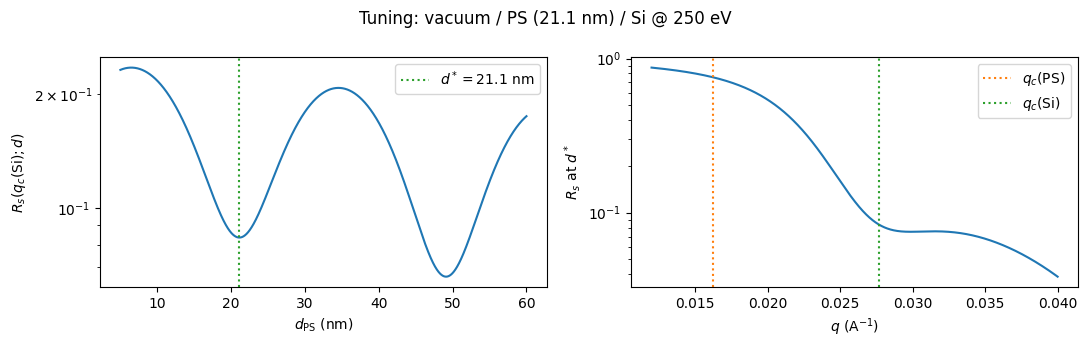

In [3]:
q_c_ps = 2.0 * k0 * np.sqrt(2.0 * (1.0 - n_ps.real))
q_c_si = 2.0 * k0 * np.sqrt(2.0 * (1.0 - n_si.real))
kz_film_qcsi = kz_of(eps_of(n_ps), kx_of(q_c_si))
half_wave_a = float(np.pi / kz_film_qcsi.real)

n_trial = [n_vac, n_ps, n_si]


def r_s_of_d(d_a: float, q: float = q_c_si) -> complex:
    return multilayer_amplitudes(q, "s", n_trial, [0.0, d_a, 0.0])[1][0]


d_grid = np.linspace(50.0, 600.0, 5501)
r_grid = np.array([abs(r_s_of_d(d)) ** 2 for d in d_grid])
d_coarse = float(d_grid[argrelmin(r_grid, order=30)[0][0]])  # lowest order
res = minimize_scalar(
    lambda d: abs(r_s_of_d(d)) ** 2, bracket=(d_coarse - 15.0, d_coarse, d_coarse + 15.0)
)
PS_A = float(res.x)
PS_NM = PS_A / 10.0
TOP_NM = PS_NM

N_LIST = [n_vac, n_ps, n_si]
D_LIST = [0.0, PS_A, 0.0]

print(f"q_c(PS) = {q_c_ps:.6f} A^-1 (grazing {grazing_angle_deg(q_c_ps):.3f} deg)")
print(f"q_c(Si) = {q_c_si:.6f} A^-1 (grazing {grazing_angle_deg(q_c_si):.3f} deg)")
print(f"half-wave estimate pi/kz_PS = {half_wave_a / 10:.2f} nm")
print(f"tuned thickness d* = {PS_A:.2f} A = {PS_NM:.2f} nm (lowest order)")
print(f"R_s(q_c(Si); d*) = {abs(r_s_of_d(PS_A)) ** 2:.5f}")

# stack arrays for the 4x4 cross-check
layers = [
    Layer(0.0, 0.0, Material("scalar"), complex(1.0, 0.0)),
    Layer(PS_A, 0.0, Material("uniaxial"), ps_n),
    Layer(0.0, 0.0, Material("scalar"), si_n),
]
slabs = np.asarray(stack_slabs(layers, energy=ENERGY_EV), dtype=np.float64)
tensor = np.asarray(stack_tensor(layers, energy=ENERGY_EV), dtype=np.complex128)


def amplitudes_4x4_corrected(q: float) -> tuple[complex, complex]:
    """(r_ss, r_pp) from the 4x4 M matrix with corrected labels.

    tjf4x4 orders modes (extraordinary +/-, ordinary +/-); with optic axis z
    the extraordinary block is p, so the docstring labels in
    ``calculate_output`` are swapped.
    """
    *_, m_full = uniaxial_reflectivity(np.asarray([q]), slabs, tensor, ENERGY_EV)
    m = m_full[0]
    denom = m[0, 0] * m[2, 2] - m[0, 2] * m[2, 0]
    r_pp = (m[1, 0] * m[2, 2] - m[1, 2] * m[2, 0]) / denom
    r_ss = (m[0, 0] * m[3, 2] - m[3, 0] * m[0, 2]) / denom
    return complex(r_ss), complex(r_pp)


fig, (ax_d, ax_q) = plt.subplots(1, 2, figsize=(11, 3.5))
ax_d.semilogy(d_grid / 10.0, r_grid)
ax_d.axvline(PS_NM, color="C2", ls=":", label=rf"$d^* = {PS_NM:.1f}$ nm")
ax_d.set_xlabel(r"$d_\mathrm{PS}$ (nm)")
ax_d.set_ylabel(r"$R_s(q_c(\mathrm{Si}); d)$")
ax_d.legend()

q_zoom = np.linspace(0.012, 0.04, 3000)
R_zoom = np.array([abs(multilayer_amplitudes(q, "s")[1][0]) ** 2 for q in q_zoom])
ax_q.semilogy(q_zoom, R_zoom)
ax_q.axvline(q_c_ps, color="C1", ls=":", label=r"$q_c(\mathrm{PS})$")
ax_q.axvline(q_c_si, color="C2", ls=":", label=r"$q_c(\mathrm{Si})$")
ax_q.set_xlabel(r"$q$ (A$^{-1}$)")
ax_q.set_ylabel(r"$R_s$ at $d^*$")
ax_q.legend()
fig.suptitle(f"Tuning: vacuum / PS ({PS_NM:.1f} nm) / Si @ 250 eV")
fig.tight_layout()

## Reflectivity

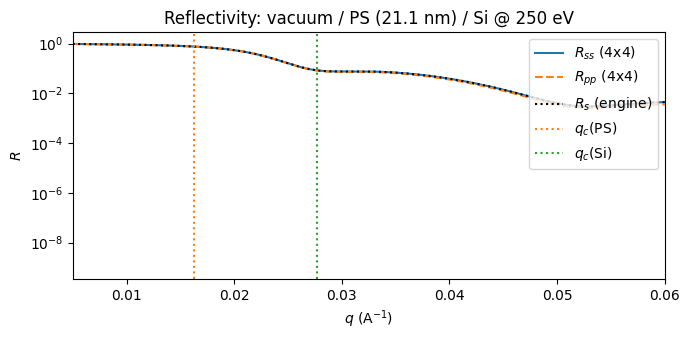

In [4]:
q_scan = np.linspace(0.0005, 0.2, 6000)
refl4, *_ = uniaxial_reflectivity(q_scan, slabs, tensor, ENERGY_EV)
R_pp_scan = refl4[:, 0, 0]  # corrected labels
R_ss_scan = refl4[:, 1, 1]
R_s_eng = np.array([abs(multilayer_amplitudes(q, "s")[1][0]) ** 2 for q in q_scan])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(q_scan, R_ss_scan, label=r"$R_{ss}$ (4x4)")
ax.semilogy(q_scan, R_pp_scan, label=r"$R_{pp}$ (4x4)", ls="--")
ax.semilogy(q_scan, R_s_eng, label=r"$R_s$ (engine)", ls=":", c="k")
ax.axvline(q_c_ps, color="C1", ls=":", label=r"$q_c(\mathrm{PS})$")
ax.axvline(q_c_si, color="C2", ls=":", label=r"$q_c(\mathrm{Si})$")
ax.set_xlabel(r"$q$ (A$^{-1}$)")
ax.set_ylabel(r"$R$")
ax.set_title(f"Reflectivity: vacuum / PS ({PS_NM:.1f} nm) / Si @ 250 eV")
ax.legend(loc="upper right")
ax.set_xlim(0.005, 0.06)
fig.tight_layout()

## Validation invariants

Same acceptance gate as the oxide version: engine $r$ equals the corrected
4x4 amplitudes, the substrate backward amplitude vanishes, tangential fields
are continuous at both interfaces, and $R + T + A = 1$ with $A$ from
$(k_0^2/k_{z,0})\int \mathrm{Im}\,\varepsilon\,|E|^2\,dz$ over the film.

In [5]:
INTERFACES_A = [0.0, PS_A]
q_check = [q_c_ps, q_c_si, 0.05, 0.15]
eps_step = 1e-9

for q in q_check:
    r_ss4, r_pp4 = amplitudes_4x4_corrected(q)
    r_s = multilayer_amplitudes(q, "s")[1][0]
    r_p = multilayer_amplitudes(q, "p")[1][0]
    assert abs(r_s - r_ss4) < 1e-10, (q, "s", abs(r_s - r_ss4))
    assert abs(r_p - r_pp4) < 1e-10, (q, "p", abs(r_p - r_pp4))

    kx = kx_of(q)
    kz0 = kz_of(eps_of(n_vac), kx).real
    for pol in ("s", "p"):
        amp_f, amp_b, kz, eps, _, _ = multilayer_amplitudes(q, pol)
        assert abs(amp_b[-1]) / abs(amp_f[-1]) < 1e-10, (q, pol)
        for z_i in INTERFACES_A:
            lo = field_profile(q, np.array([z_i - eps_step]), pol)
            hi = field_profile(q, np.array([z_i + eps_step]), pol)
            comp = 1 if pol == "s" else 0  # E_y or E_x
            jump = abs(lo[comp][0] - hi[comp][0]) / max(abs(lo[comp][0]), 1e-30)
            assert jump < 1e-9, (q, pol, z_i, jump)
        refl_frac = abs(amp_b[0]) ** 2
        if pol == "s":
            tran_frac = (kz[-1].real / kz0) * abs(amp_f[-1]) ** 2
        else:
            tran_frac = ((kz[-1] / eps[-1]).real / kz0) * abs(amp_f[-1]) ** 2
        z_fine = np.linspace(0.0, PS_A, 100001)
        ex, ey, ez = field_profile(q, z_fine, pol)
        e2 = np.abs(ex) ** 2 + np.abs(ey) ** 2 + np.abs(ez) ** 2
        im_eps_film = eps_of(n_ps).imag
        absorbed = (k0**2 / kz0) * np.trapezoid(im_eps_film * e2, z_fine)
        resid = 1.0 - refl_frac - tran_frac - absorbed
        assert abs(resid) < 5e-4, (q, pol, resid)

print("all invariants pass: 4x4 cross-check, B_sub = 0, continuity, R + T + A = 1")

all invariants pass: 4x4 cross-check, B_sub = 0, continuity, R + T + A = 1


## Field maps (lab frame, beam from the top)

At $q_c(\mathrm{Si})$ the film holds the lowest-order standing wave; the
vacuum fringes have period $2\pi/q \approx 22.7$ nm. At $q_c(\mathrm{PS})$
the film is at its own TER edge and the field decays into it.

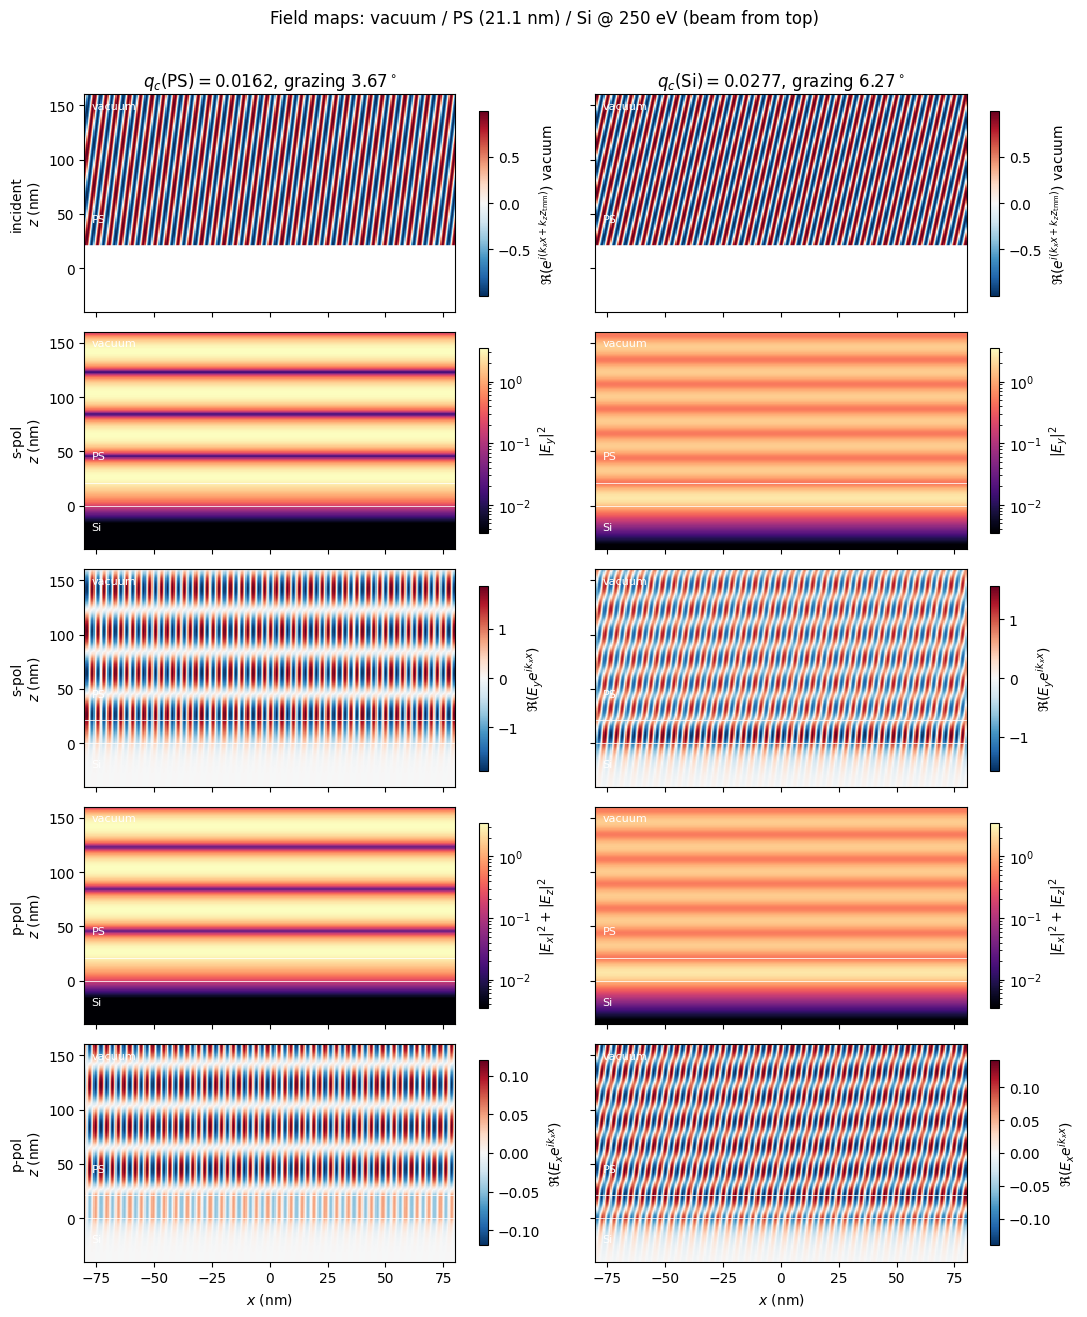

In [6]:
x_nm = np.linspace(-80.0, 80.0, 320)
z_nm = np.linspace(-40.0, 160.0, 400)
x_a, z_lab_a = x_nm * 10.0, z_nm * 10.0

conditions = {
    rf"$q_c(\mathrm{{PS}}) = {q_c_ps:.4f}$, grazing ${grazing_angle_deg(q_c_ps):.2f}^\circ$": q_c_ps,
    rf"$q_c(\mathrm{{Si}}) = {q_c_si:.4f}$, grazing ${grazing_angle_deg(q_c_si):.2f}^\circ$": q_c_si,
}

panels = []
for label, q_val in conditions.items():
    kx = kx_of(q_val)
    z_tmm = lab_to_tmm(z_lab_a)
    _, ey_s, _ = field_profile(q_val, z_tmm, "s")
    ex_p, _, ez_p = field_profile(q_val, z_tmm, "p")
    xph = np.exp(1j * kx * x_a)[None, :]
    kz0 = kz_of(eps_of(n_vac), kx)
    inc = np.real(np.exp(1j * (kx * x_a[None, :] + kz0 * z_tmm[:, None])))
    inc = np.where(z_lab_a[:, None] > PS_A, inc, np.nan)
    ones = np.ones_like(x_a)[None, :]
    panels.append(
        (
            label,
            {
                "inc": inc,
                "s_den": (np.abs(ey_s) ** 2)[:, None] * ones,
                "s_re": np.real(ey_s[:, None] * xph),
                "p_den": (np.abs(ex_p) ** 2 + np.abs(ez_p) ** 2)[:, None] * ones,
                "p_re": np.real(ex_p[:, None] * xph),
            },
        )
    )

vmax_s = max(np.nanmax(p[1]["s_den"]) for p in panels)
vmax_p = max(np.nanmax(p[1]["p_den"]) for p in panels)
row_defs = [
    ("inc", r"$\Re(e^{i(k_x x + k_z z_\mathrm{tmm})})$ vacuum", "RdBu_r", None),
    ("s_den", r"$|E_y|^2$", "magma", LogNorm(vmin=vmax_s * 1e-3, vmax=vmax_s)),
    ("s_re", r"$\Re(E_y e^{ik_x x})$", "RdBu_r", None),
    ("p_den", r"$|E_x|^2+|E_z|^2$", "magma", LogNorm(vmin=vmax_p * 1e-3, vmax=vmax_p)),
    ("p_re", r"$\Re(E_x e^{ik_x x})$", "RdBu_r", None),
]

fig, axes = plt.subplots(
    len(row_defs), 2, figsize=(11, 2.6 * len(row_defs)), sharex=True, sharey=True
)
for col, (label, maps) in enumerate(panels):
    for rix, (key, ylab, cmap, norm) in enumerate(row_defs):
        ax = axes[rix, col]
        im = ax.pcolormesh(x_nm, z_nm, maps[key], shading="auto", cmap=cmap, norm=norm)
        for z_line in (0.0, PS_NM):
            ax.axhline(z_line, color="w", lw=0.7, alpha=0.8)
        ax.text(0.02, 0.97, "vacuum", transform=ax.transAxes, va="top", color="w", fontsize=8)
        ax.text(0.02, 0.45, "PS", transform=ax.transAxes, va="top", color="w", fontsize=8)
        ax.text(0.02, 0.08, "Si", transform=ax.transAxes, va="bottom", color="w", fontsize=8)
        if rix == 0:
            ax.set_title(label)
        if col == 0:
            row_label = "incident" if key == "inc" else ("s-pol" if key.startswith("s") else "p-pol")
            ax.set_ylabel(f"{row_label}\n$z$ (nm)")
        fig.colorbar(im, ax=ax, label=ylab, shrink=0.85)
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x$ (nm)")
fig.suptitle(
    f"Field maps: vacuum / PS ({PS_NM:.1f} nm) / Si @ 250 eV (beam from top)", y=1.01
)
fig.tight_layout()
plt.show()

## Depth profiles

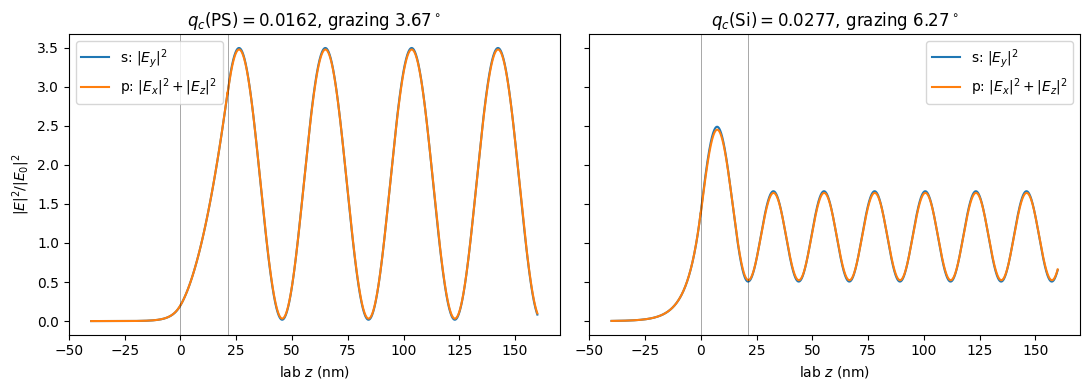

In [7]:
fig, ax2 = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
zp_nm = np.linspace(-40.0, 160.0, 3000)
for axi, (label, q_val) in zip(ax2, conditions.items()):
    z_tmm = lab_to_tmm(zp_nm * 10.0)
    _, ey_s, _ = field_profile(q_val, z_tmm, "s")
    ex_p, _, ez_p = field_profile(q_val, z_tmm, "p")
    axi.plot(zp_nm, np.abs(ey_s) ** 2, label=r"s: $|E_y|^2$")
    axi.plot(zp_nm, np.abs(ex_p) ** 2 + np.abs(ez_p) ** 2, label=r"p: $|E_x|^2+|E_z|^2$")
    for z_line in (0.0, PS_NM):
        axi.axvline(z_line, color="k", lw=0.6, alpha=0.4)
    axi.set_title(label)
    axi.set_xlabel(r"lab $z$ (nm)")
    axi.legend()
ax2[0].set_ylabel(r"$|E|^2 / |E_0|^2$")
fig.tight_layout()
plt.show()

## Export for MaxwellNet / JCM parity

Same archive layout as the oxide version, three regions. Angles are
**grazing**; a JCM source specified from the normal needs
$\theta_\mathrm{normal} = 90^\circ - \theta_\mathrm{grazing}$.

In [ ]:
REGION_NAMES = np.array(["vacuum", "PS", "Si"])
N_BY_REGION = np.array(N_LIST, dtype=np.complex128)


def optical_constant_stack_map(x_a, z_lab_a):
    """Per-pixel n, delta, beta, region (0 vacuum, 1 PS, 2 Si)."""
    _xg, zg = np.meshgrid(x_a, z_lab_a, indexing="xy")
    region = np.full(zg.shape, 2, dtype=np.uint8)  # default Si (z < 0)
    region[zg >= 0.0] = 1
    region[zg > PS_A] = 0
    n_map = N_BY_REGION[region]
    delta_beta = 1.0 - n_map
    return n_map, np.real(delta_beta), np.imag(delta_beta), region


def e_field_vector_maps(q_val, x_a, z_lab_a, pol):
    """Complex (E_x, E_y, E_z) on the lab-frame grid including e^{i k_x x}."""
    kx = kx_of(q_val)
    xph = np.exp(1j * kx * x_a)[None, :]
    ex_z, ey_z, ez_z = field_profile(q_val, lab_to_tmm(z_lab_a), pol)
    return ex_z[:, None] * xph, ey_z[:, None] * xph, ez_z[:, None] * xph


def export_test_structures_npz(
    x_nm, z_nm, q_values, *, out_dir="examples/test_structures_output"
):
    export_root = Path(out_dir)
    export_root.mkdir(parents=True, exist_ok=True)
    x_a, z_lab_a = x_nm * 10.0, z_nm * 10.0

    n_map, delta_map, beta_map, region = optical_constant_stack_map(x_a, z_lab_a)
    stack_path = export_root / "optical_stack.npz"
    np.savez(
        stack_path,
        x_nm=x_nm,
        z_nm=z_nm,
        energy_ev=np.float64(ENERGY_EV),
        ps_thickness_nm=np.float64(PS_NM),
        n_real=np.real(n_map),
        n_imag=np.imag(n_map),
        delta=delta_map,
        beta=beta_map,
        region=region,
        region_names=REGION_NAMES,
        n_by_region=N_BY_REGION,
    )

    field_paths = []
    for tag, q_val in q_values.items():
        ex_s, ey_s, ez_s = e_field_vector_maps(q_val, x_a, z_lab_a, "s")
        ex_p, ey_p, ez_p = e_field_vector_maps(q_val, x_a, z_lab_a, "p")
        field_path = export_root / f"e_fields_{tag}.npz"
        np.savez(
            field_path,
            x_nm=x_nm,
            z_nm=z_nm,
            q=np.float64(q_val),
            grazing_angle_deg=np.float64(grazing_angle_deg(q_val)),
            theta_from_normal_deg=np.float64(90.0 - grazing_angle_deg(q_val)),
            energy_ev=np.float64(ENERGY_EV),
            ps_thickness_nm=np.float64(PS_NM),
            Ex_s=ex_s,
            Ey_s=ey_s,
            Ez_s=ez_s,
            Ex_p=ex_p,
            Ey_p=ey_p,
            Ez_p=ez_p,
        )
        field_paths.append(field_path)
    return stack_path, field_paths


stack_npz, field_npz_paths = export_test_structures_npz(
    x_nm, z_nm, {"qc_ps": q_c_ps, "qc_si": q_c_si}
)
print(f"optical stack: {stack_npz.resolve()}")
for path in field_npz_paths:
    print(f"E fields:      {path.resolve()}")
with np.load(stack_npz) as data:
    print("stack arrays:", sorted(k for k in data.files if k != "region_names"))
with np.load(field_npz_paths[0]) as data:
    print("field arrays:", sorted(data.files))
    print(
        f"  grid {data['Ex_s'].shape}, q = {float(data['q']):.6f} A^-1, "
        f"grazing = {float(data['grazing_angle_deg']):.3f} deg"
    )